# Performance Evolution of CNN and ViT with Scaled-Down CIFAR-10 Training Data

The research question of this project is whether the classification accuracy of ViT will be less than CNN as the training data volume of CIFAR-10 is scaled down from 100% to an extreme low level of 10%.

Our primary objective is to evaluate these two model under a controlled and fair constraints, comparing the change of classification accuracy across various data scales.

Also it is necessary to investigate that the reason of ViT's failure in toy dataset is a lack of convergence or an overfitting of the limited training dataset.

## Data Preparation

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import cv2
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torch.utils.data import DataLoader

import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Download the CIFAR-10 dataset

In PyTorch, the CIFAR-10 dataset has already been splitted into training set and test set.

* Training set: 50,000 images

* Test set: 10,000 images

Data augmentation is applied to increase the diversity of the training data and improve model generalization. This is particularly important when the training data is limited, as it helps reduce overfitting.

In [ ]:
# 1. define data preparation
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 2. download dataset
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:02<00:00, 64.0MB/s] 


### Overview of the CIFAR-10 classes

**CIFAR-10 Dataset**

The CIFAR-10 dataset is a well-established benchmark in the field of machine learning, specifically designed for image classification.

Comprising 60,000 color images, each of size 32x32 pixels, the dataset is segmented into 10 distinct classes, each representing a different object or creature.

The classes encompass the following:

* Airplane
* Automobile
* Bird
* Cat
* Deer
* Dog
* Frog
* Horse
* Ship
* Truck

Each class contains an equal distribution, boasting 60,000 images. From the total image count, 50,000 are designated for training while the remaining 10,000 are set aside for testing.

In [ ]:
# CIFAR-10 classes name
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

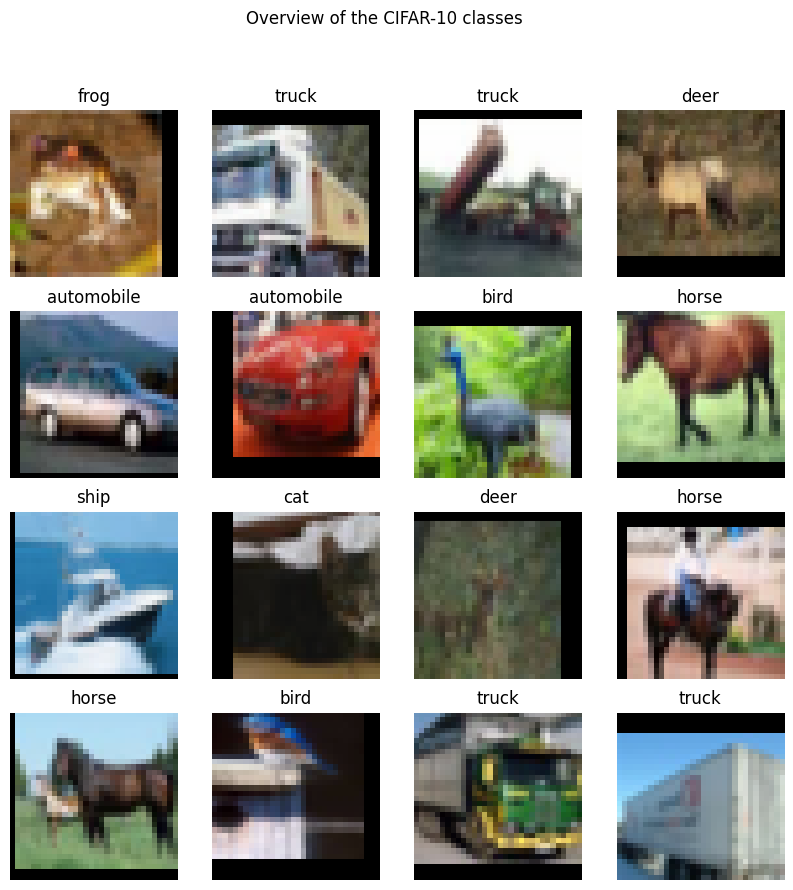

In [ ]:
plt.figure(figsize=(10, 10))
# check the first 16 plots in CIFAR-10 dataset
for i in range(16):
    plt.subplot(4, 4, i + 1)

    img_tensor, label = full_train_dataset[i]

    # inverse normalization processing
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = np.clip(img * std + mean, 0, 1)

    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')
plt.suptitle("Overview of the CIFAR-10 classes")
plt.show()

### Generate a random subset of the dataset based on a specified ratio

The official CIFAR-10 training set is stratified randomly sampled to create 100%, 50% and 10% subsets, preserving the original class distribution to avoid sampling bias.

This function allows to evaluate CNN and ViT under a controlled and fair constraints by setting a random seed 42.

In [ ]:
def get_subset(dataset, ratio, seed=42):
  # calculate the stratification ratio
  targets = np.array(dataset.targets)
  indices = np.arange(len(targets))

  if ratio == 1.0:
      return dataset

  subset_indices, _ = train_test_split(
      indices,
      train_size=ratio, # create different ratio training subsets
      stratify=targets, # segment by stratification ratio
      random_state=seed
  )

  return Subset(dataset, subset_indices)

Define different data sizes, and set DataLoader for training set and test set.

In [ ]:
scales = [0.1, 0.5, 1.0]

trainloaders = {}

for i, scale in enumerate(scales):
  # subset of each ratio
  subset = get_subset(full_train_dataset, scale)

  # DataLoader for training subsets
  trainloaders[i] = DataLoader(
      subset,
      batch_size=64,
      shuffle=True,
      num_workers=2,
      pin_memory=True
  )

# DataLoader for test set
testloader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

Check the number of training and test sets, and the distribution of each label.

In [ ]:
# check training and test set
print(f"Total Train Samples: {len(full_train_dataset)}")
print(f"100% Subset Samples: {len(trainloaders[2].dataset)}")
print(f"50% Subset Samples: {len(trainloaders[1].dataset)}")
print(f"10% Subset Samples: {len(trainloaders[0].dataset)}")
print(f"Test Samples: {len(test_dataset)}")

# check shape
images, labels = next(iter(trainloaders[0]))
print(f"\nBatch Images Shape: {images.shape}")  # [64, 3, 32, 32]
print(f"Batch Labels Shape: {labels.shape}")    # [64]

Total Train Samples: 50000
100% Subset Samples: 50000
50% Subset Samples: 25000
10% Subset Samples: 5000
Test Samples: 10000

Batch Images Shape: torch.Size([64, 3, 32, 32])
Batch Labels Shape: torch.Size([64])


In [ ]:
# check training subsets distribution
for scale, loader in trainloaders.items():
    # 0 -> 10%, 1 -> 50%, 2 -> 100%

    indices = loader.dataset.indices if isinstance(loader.dataset, Subset) else range(len(loader.dataset))
    labels = [full_train_dataset.targets[i] for i in indices]
    unique, counts = np.unique(labels, return_counts=True)
    train_dict = {int(k): int(v) for k, v in zip(unique, counts)}
    print(f"Scale Index {scale} ({len(labels)} samples):")
    print(f"  {train_dict}")


# check test set distribution
test_labels = [test_dataset.targets[i] for i in range(len(test_dataset))]
t_unique, t_counts = np.unique(test_labels, return_counts=True)
test_dict = {int(k): int(v) for k, v in zip(t_unique, t_counts)}
print(f"Test Set:")
print(f"  {test_dict}")

Scale Index 0 (5000 samples):
  {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Scale Index 1 (25000 samples):
  {0: 2500, 1: 2500, 2: 2500, 3: 2500, 4: 2500, 5: 2500, 6: 2500, 7: 2500, 8: 2500, 9: 2500}
Scale Index 2 (50000 samples):
  {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}
Test Set:
  {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


According to the output, stratified randomly sample is successfully.

## Model Training

In [ ]:
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

### Training Function

The train_one_epoch function implements a single pass over the training dataset.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    acc = 100. * correct / total

    return avg_loss, acc

### Evaluation Function

The evaluate function is designed to assess the model's performance on the training and test set.

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    acc = 100. * correct / total

    return avg_loss, acc

### Model Architecture: Convolutional Neural Network (ResNet-18)

To adapt the standard ResNet-18 architecture for the low-resolution CIFAR-10 dataset (32x32 pixels), we implement the following modifications:

1. First Convolutional Layer: We replaced the default 7×7 kernel (stride 2) with a 3×3 kernel (stride 1). This prevents excessive downsampling at the very beginning of the network, which would otherwise lead to significant loss of fine-grained spatial features.

2. Initial Max Pooling: We replaced the initial maxpool layer with an Identity() layer. Removing this pooling step ensures that the feature map dimensions remain large enough for the subsequent residual blocks to extract meaningful patterns.

3. Output Layer: The fully connected layer is configured with num_classes=10 to match the CIFAR-10 categories.

4. Rationale: These changes are standard practice for training ResNet on CIFAR-10, as they allow the model to maintain a 32×32 feature map resolution for a longer duration, leading to significantly higher accuracy compared to the "out-of-the-box" ImageNet version.

In [ ]:
def get_cifar_resnet18():
    # load ResNet-18
    model = models.resnet18(weights=None, num_classes=10)

    # modify the first convolutional layer：
    # 7x7, stride=2 -> 3x3, stride=1
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # remove the initial max pooling layer
    model.maxpool = nn.Identity()

    return model

### Train CNN model

1. Setup device-agnostic training and define cross-entropy loss.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()

# save loss and accuracy results
results_cnn = {}

2. Train CNN model and print performance metrics.

In [ ]:
for i, scale in enumerate(scales):
  results_cnn[i] = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
  }
  print("\n" + "-"*30)
  print(f"Training scale: {scale*100}%")
  print("-"*30)

  # reinitialize the CNN model
  cnn = get_cifar_resnet18().to(device)

  optimizer = optim.SGD(
      cnn.parameters(),
      lr=0.01,
      momentum=0.9,
      weight_decay=5e-4
  )

  num_epochs = 30
  scheduler = optim.lr_scheduler.CosineAnnealingLR(
      optimizer,
      T_max=num_epochs
  )

  trainloader = trainloaders[i]

  # training loop
  for epoch in range(num_epochs):
    # calculate loss and accuracy
    train_loss, train_acc = train_one_epoch(
      cnn, trainloader, optimizer, criterion, device
    )

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch < 5:
      test_loss, test_acc = evaluate(
        cnn, testloader, criterion, device
      )
      # save loss and accuracy
      results_cnn[i]["train_loss"].append(train_loss)
      results_cnn[i]["test_loss"].append(test_loss)
      results_cnn[i]["train_acc"].append(train_acc)
      results_cnn[i]["test_acc"].append(test_acc)
      print(f"Epoch [{epoch+1}/{num_epochs}] "
        f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
        f"- Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")


  torch.save(cnn.state_dict(), f'resnet18_scale_{int(scale*100)}.pth')
  print(f"Training set: {scale}, complete.")


------------------------------
Training scale: 10.0%
------------------------------
Epoch [1/30] - Train Loss: 2.0622, Train Acc: 23.44% - Test Loss: 2.0116, Test Acc: 26.56%
Epoch [2/30] - Train Loss: 1.7612, Train Acc: 35.40% - Test Loss: 2.0346, Test Acc: 32.94%
Epoch [3/30] - Train Loss: 1.6516, Train Acc: 39.56% - Test Loss: 1.7908, Test Acc: 36.26%
Epoch [4/30] - Train Loss: 1.5179, Train Acc: 43.70% - Test Loss: 1.5762, Test Acc: 44.07%
Epoch [5/30] - Train Loss: 1.4499, Train Acc: 47.36% - Test Loss: 1.4733, Test Acc: 47.14%
Epoch [10/30] - Train Loss: 1.1123, Train Acc: 60.02% - Test Loss: 1.3927, Test Acc: 51.05%
Epoch [15/30] - Train Loss: 0.7916, Train Acc: 71.60% - Test Loss: 1.1477, Test Acc: 62.08%
Epoch [20/30] - Train Loss: 0.5540, Train Acc: 80.54% - Test Loss: 1.0905, Test Acc: 64.57%
Epoch [25/30] - Train Loss: 0.3762, Train Acc: 86.82% - Test Loss: 0.9597, Test Acc: 68.92%
Epoch [30/30] - Train Loss: 0.3126, Train Acc: 89.80% - Test Loss: 0.9666, Test Acc: 69.19%


a. A clear positive correlation between the volume of


training data and the model performance.

There was a significantly upward trend in final test accuracy, and the test loss dropped sharply as the volume of training set increased.

ResNet-18 model became more precise in classification task when it was exposed to a more diverse range of training samples.

b. Diminishing returns.

There was the most substantial performance gain when increasing the data from 10% to 50%.

However, when increasing the training scale further from 50% to 100%, the improvement of test accuracy was only 4.12%.

3. Visualization: plot the loss/accuracy of each training scale.

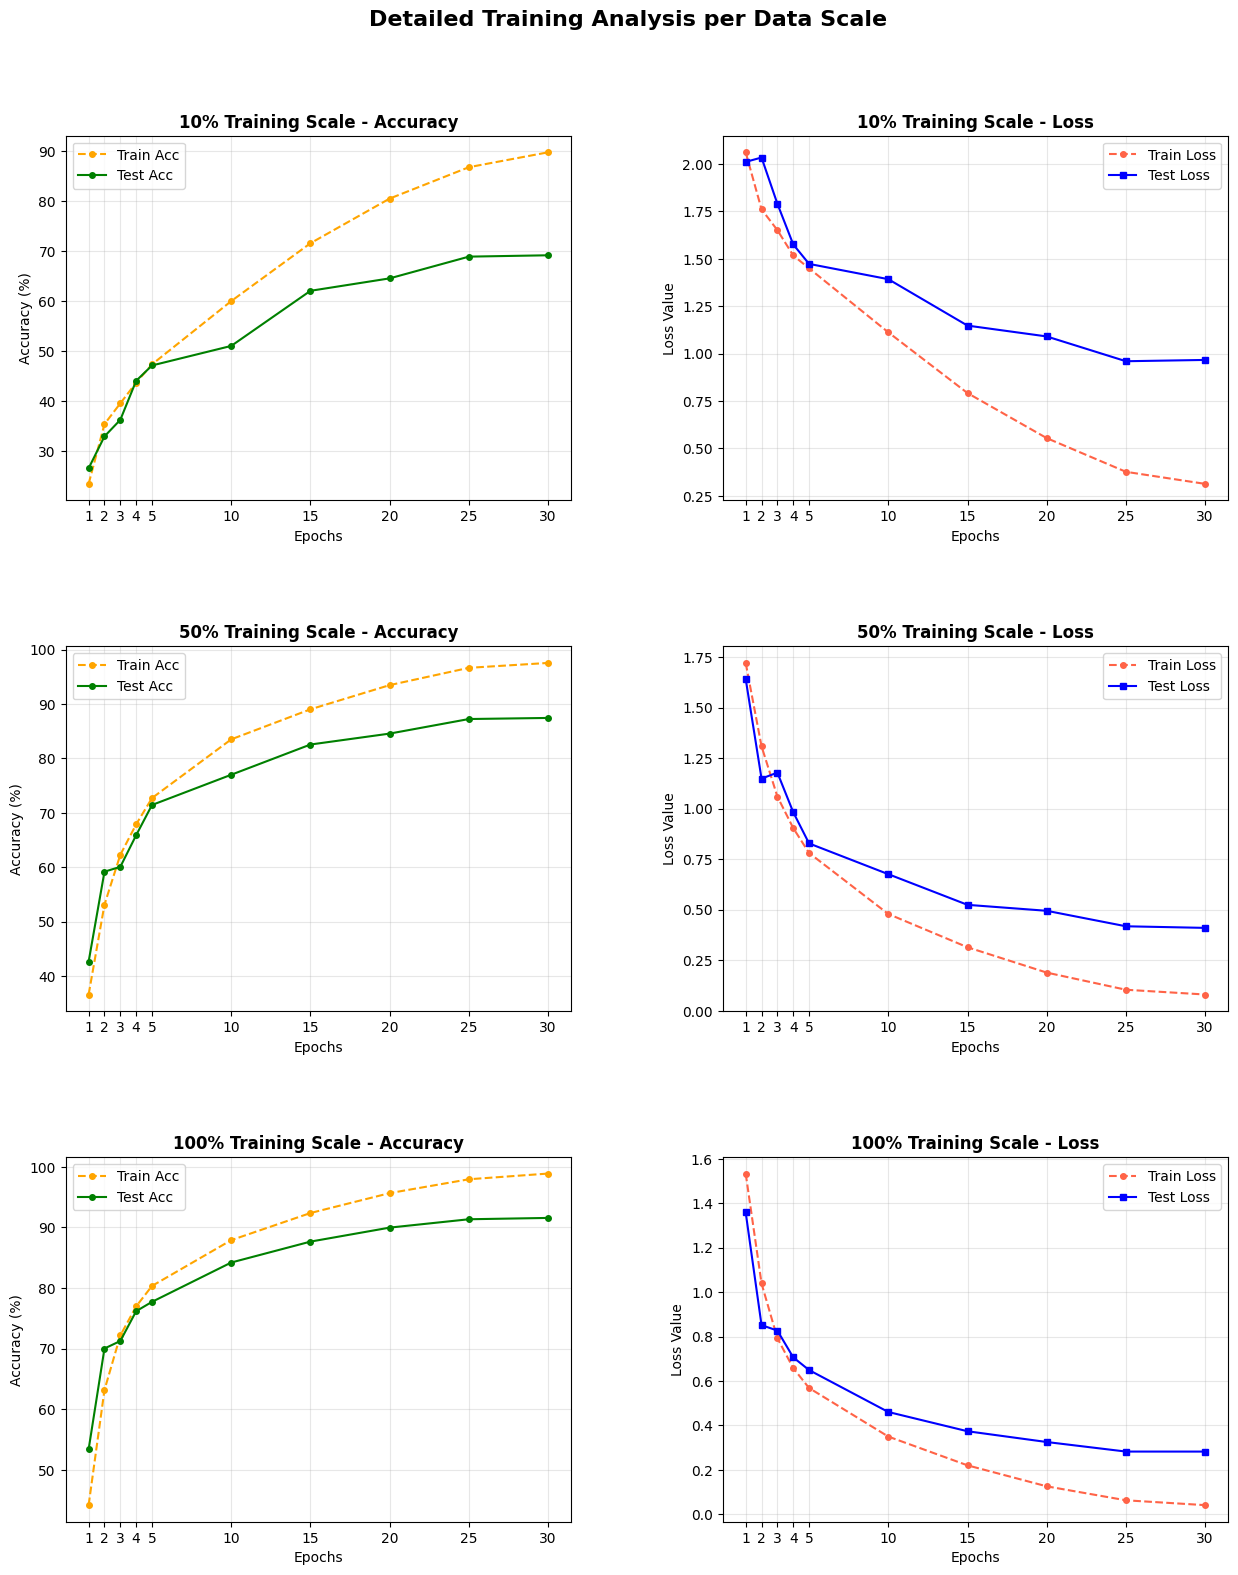

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

epochs = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]
titles = ["10% Training Scale", "50% Training Scale", "100% Training Scale"]

for i in range(3):
    # accuracy plot
    ax_acc = axes[i, 0]
    ax_acc.plot(epochs, results_cnn[i]["train_acc"], label='Train Acc', color='orange',
                linestyle='--', marker='o', markersize=4)
    ax_acc.plot(epochs, results_cnn[i]["test_acc"], label='Test Acc', color='green',
                marker='o', markersize=4)
    ax_acc.set_title(f"{titles[i]} - Accuracy", fontweight='bold')
    ax_acc.set_xlabel("Epochs")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.set_xticks(epochs)
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    # loss plot
    ax_loss = axes[i, 1]
    ax_loss.plot(epochs, results_cnn[i]["train_loss"], label='Train Loss', color='tomato',
                 linestyle='--', marker='o', markersize=4)
    ax_loss.plot(epochs, results_cnn[i]["test_loss"], label='Test Loss', color='blue',
                 marker='s', markersize=4)
    ax_loss.set_title(f"{titles[i]} - Loss", fontweight='bold')
    ax_loss.set_xlabel("Epochs")
    ax_loss.set_ylabel("Loss Value")
    ax_loss.set_xticks(epochs)
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

plt.suptitle("Detailed Training Analysis per Data Scale", fontsize=16, y=0.95, fontweight='black')
plt.show()

a. ResNet-18 exhibited fast learning within the first 5 to 10 epochs, where the loss showed decrease and accuracy showed improvement clearly.

b. At the 10% scale, there was a significant divergence between training and testing curves on early epochs.

After Epoch 10, the training loss continued to drop while the test loss began to stagnate, visually confirming the extreme overfitting discussed previously.

c. At the 50% and 100% scales, the overfitting was handled. The curves for training and testing remained much closer.

The test loss continued to decrease and the test accuracy increased steadily throughout the 30 epochs, suggesting that the model was effectively learning generalizable features.

d. The curve became smoother while increasing the data volume.

### Train ViT model

In [ ]:
from torchvision.models.vision_transformer import VisionTransformer

In [ ]:
def get_cifar_vit_tiny():
    model = VisionTransformer(
        image_size=32,
        patch_size=4,
        num_layers=6,
        num_heads=3,
        hidden_dim=192,
        mlp_dim=768,
        num_classes=10,
        dropout=0.1,
        attention_dropout=0.1
    )
    return model

In [ ]:
results_vit = {}

for i, scale in enumerate(scales):
    results_vit[i] = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }


    print(f"Training scale: {scale*100}%")


    vit = get_cifar_vit_tiny().to(device)

    optimizer = optim.AdamW(
        vit.parameters(),
        lr=3e-4,
        weight_decay=0.05
    )

    num_epochs = 30
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs
    )

    trainloader = trainloaders[i]

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            vit, trainloader, optimizer, criterion, device
        )

        scheduler.step()

        if (epoch + 1) % 5 == 0 or epoch < 5:
            test_loss, test_acc = evaluate(
                vit, testloader, criterion, device
            )

            results_vit[i]["train_loss"].append(train_loss)
            results_vit[i]["test_loss"].append(test_loss)
            results_vit[i]["train_acc"].append(train_acc)
            results_vit[i]["test_acc"].append(test_acc)

            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
                f"- Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
            )

    torch.save(vit.state_dict(), f"vit_tiny_scale_{int(scale*100)}.pth")
    print(f"Training set: {scale}, complete.")

Training scale: 10.0%
Epoch [1/30] - Train Loss: 2.0891, Train Acc: 21.80% - Test Loss: 1.9775, Test Acc: 25.51%
Epoch [2/30] - Train Loss: 1.9489, Train Acc: 26.22% - Test Loss: 1.9248, Test Acc: 26.09%
Epoch [3/30] - Train Loss: 1.8689, Train Acc: 28.26% - Test Loss: 1.8081, Test Acc: 32.08%
Epoch [4/30] - Train Loss: 1.8102, Train Acc: 30.48% - Test Loss: 1.8004, Test Acc: 32.59%
Epoch [5/30] - Train Loss: 1.7788, Train Acc: 32.34% - Test Loss: 1.7526, Test Acc: 33.40%
Epoch [10/30] - Train Loss: 1.5926, Train Acc: 40.84% - Test Loss: 1.5986, Test Acc: 41.07%
Epoch [15/30] - Train Loss: 1.4218, Train Acc: 48.10% - Test Loss: 1.5172, Test Acc: 44.30%
Epoch [20/30] - Train Loss: 1.3210, Train Acc: 52.40% - Test Loss: 1.4244, Test Acc: 49.25%
Epoch [25/30] - Train Loss: 1.2035, Train Acc: 56.80% - Test Loss: 1.3880, Test Acc: 49.92%
Epoch [30/30] - Train Loss: 1.1710, Train Acc: 57.52% - Test Loss: 1.3602, Test Acc: 51.45%
Training set: 0.1, complete.
Training scale: 50.0%
Epoch [1/30]

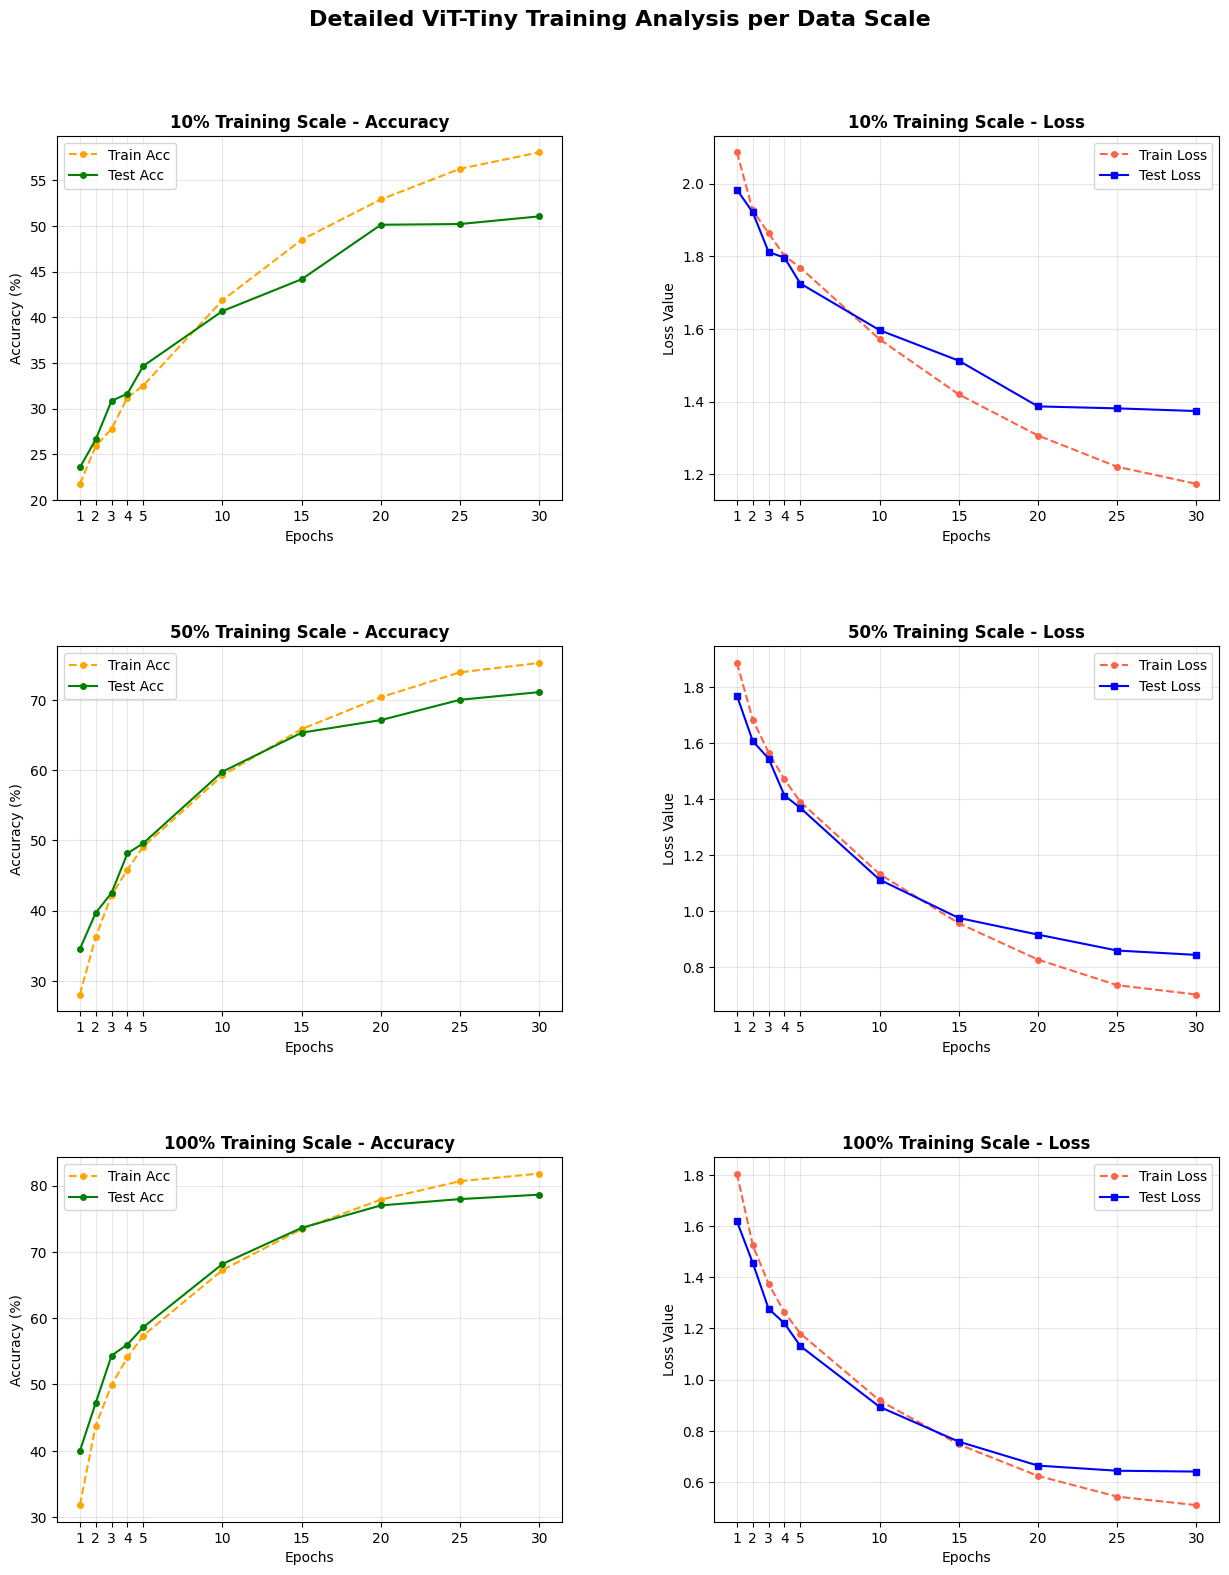

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

epochs = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]
titles = ["10% Training Scale", "50% Training Scale", "100% Training Scale"]

for i in range(3):
    ax_acc = axes[i, 0]
    ax_acc.plot(epochs, results_vit[i]["train_acc"], label='Train Acc', color='orange',
                linestyle='--', marker='o', markersize=4)
    ax_acc.plot(epochs, results_vit[i]["test_acc"], label='Test Acc', color='green',
                marker='o', markersize=4)
    ax_acc.set_title(f"{titles[i]} - Accuracy", fontweight='bold')
    ax_acc.set_xlabel("Epochs")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.set_xticks(epochs)
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    ax_loss = axes[i, 1]
    ax_loss.plot(epochs, results_vit[i]["train_loss"], label='Train Loss', color='tomato',
                 linestyle='--', marker='o', markersize=4)
    ax_loss.plot(epochs, results_vit[i]["test_loss"], label='Test Loss', color='blue',
                 marker='s', markersize=4)
    ax_loss.set_title(f"{titles[i]} - Loss", fontweight='bold')
    ax_loss.set_xlabel("Epochs")
    ax_loss.set_ylabel("Loss Value")
    ax_loss.set_xticks(epochs)
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

plt.suptitle("Detailed ViT-Tiny Training Analysis per Data Scale", fontsize=16, y=0.95, fontweight='black')
plt.show()

The main experiment showed that ViT outperformed CNN across all three data scales, with the difference being particularly pronounced in the 10% low-data setting. Therefore, two fallback experiments were designed to diagnose the reasons for ViT's poor performance under low-data conditions.

### 1. 10% + longer training + warmup + AdamW

In [ ]:
# ### Fallback Experiment 1: 10% subset with longer training + warmup + AdamW

results_vit_fallback1 = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": []
}

vit = get_cifar_vit_tiny().to(device)

criterion_fallback1 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    vit.parameters(),
    lr=5e-4,
    weight_decay=0.05
)

num_epochs = 50
checkpoint_epochs = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50]

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs - 5
)

warmup_epochs = 5
trainloader = trainloaders[0]   # 10% subset

for epoch in range(num_epochs):
    if epoch < warmup_epochs:
        lr = 5e-4 * (epoch + 1) / warmup_epochs
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
    else:
        scheduler.step()

    train_loss, train_acc = train_one_epoch(
        vit, trainloader, optimizer, criterion_fallback1, device
    )

    if (epoch + 1) in checkpoint_epochs:
        test_loss, test_acc = evaluate(
            vit, testloader, criterion_fallback1, device
        )

        results_vit_fallback1["train_loss"].append(train_loss)
        results_vit_fallback1["test_loss"].append(test_loss)
        results_vit_fallback1["train_acc"].append(train_acc)
        results_vit_fallback1["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
            f"- Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
        )

torch.save(vit.state_dict(), "vit_tiny_fallback1_10pct.pth")
print("Fallback complete.")


Epoch [1/50] - Train Loss: 2.1934, Train Acc: 20.44% - Test Loss: 2.0928, Test Acc: 25.25%
Epoch [2/50] - Train Loss: 2.0523, Train Acc: 25.20% - Test Loss: 1.9939, Test Acc: 28.91%
Epoch [3/50] - Train Loss: 1.9877, Train Acc: 27.48% - Test Loss: 1.9254, Test Acc: 30.85%
Epoch [4/50] - Train Loss: 1.9551, Train Acc: 28.84% - Test Loss: 1.9208, Test Acc: 30.31%
Epoch [5/50] - Train Loss: 1.9271, Train Acc: 30.88% - Test Loss: 1.9055, Test Acc: 31.77%
Epoch [10/50] - Train Loss: 1.7879, Train Acc: 38.62% - Test Loss: 1.7985, Test Acc: 38.19%
Epoch [20/50] - Train Loss: 1.5670, Train Acc: 50.70% - Test Loss: 1.6168, Test Acc: 47.56%
Epoch [30/50] - Train Loss: 1.4022, Train Acc: 58.52% - Test Loss: 1.5863, Test Acc: 51.10%
Epoch [40/50] - Train Loss: 1.2549, Train Acc: 64.94% - Test Loss: 1.4959, Test Acc: 55.50%
Epoch [50/50] - Train Loss: 1.1951, Train Acc: 68.32% - Test Loss: 1.4858, Test Acc: 56.80%
Fallback complete.


ViT's test accuracy improved from 57.52% to 68.32% of the baseline, demonstrating that a more suitable optimization strategy and longer training time can indeed significantly improve performance.

### 2.10% + stronger regularization

In [ ]:
# ### Regularized ViT-Tiny for fallback experiment

def get_cifar_vit_tiny_regularized():
    model = VisionTransformer(
        image_size=32,
        patch_size=4,
        num_layers=6,
        num_heads=3,
        hidden_dim=192,
        mlp_dim=768,
        num_classes=10,
        dropout=0.2,
        attention_dropout=0.2
    )
    return model


In [ ]:
# ### Fallback Experiment 2: 10% subset with stronger regularization

results_vit_fallback2 = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": []
}



vit = get_cifar_vit_tiny_regularized().to(device)

criterion_fallback2 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    vit.parameters(),
    lr=3e-4,
    weight_decay=0.1
)

num_epochs = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

trainloader = trainloaders[0]   # 10% subset

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        vit, trainloader, optimizer, criterion_fallback2, device
    )

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch < 5:
        test_loss, test_acc = evaluate(
            vit, testloader, criterion_fallback2, device
        )

        results_vit_fallback2["train_loss"].append(train_loss)
        results_vit_fallback2["test_loss"].append(test_loss)
        results_vit_fallback2["train_acc"].append(train_acc)
        results_vit_fallback2["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
            f"- Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
        )

torch.save(vit.state_dict(), "vit_tiny_fallback2_10pct.pth")
print("Fallback 2 complete.")


Epoch [1/30] - Train Loss: 2.1472, Train Acc: 20.10% - Test Loss: 2.0864, Test Acc: 22.11%
Epoch [2/30] - Train Loss: 2.0499, Train Acc: 24.40% - Test Loss: 2.0130, Test Acc: 25.30%
Epoch [3/30] - Train Loss: 1.9925, Train Acc: 27.54% - Test Loss: 2.0154, Test Acc: 25.20%
Epoch [4/30] - Train Loss: 1.9525, Train Acc: 28.82% - Test Loss: 1.9281, Test Acc: 29.57%
Epoch [5/30] - Train Loss: 1.9233, Train Acc: 30.68% - Test Loss: 1.9336, Test Acc: 30.71%
Epoch [10/30] - Train Loss: 1.7972, Train Acc: 37.44% - Test Loss: 1.8006, Test Acc: 37.91%
Epoch [15/30] - Train Loss: 1.6868, Train Acc: 43.30% - Test Loss: 1.7383, Test Acc: 41.88%
Epoch [20/30] - Train Loss: 1.6090, Train Acc: 48.12% - Test Loss: 1.7143, Test Acc: 43.68%
Epoch [25/30] - Train Loss: 1.5537, Train Acc: 50.98% - Test Loss: 1.6678, Test Acc: 45.88%
Epoch [30/30] - Train Loss: 1.5327, Train Acc: 51.80% - Test Loss: 1.6740, Test Acc: 45.77%
Fallback 2 complete.


The test accuracy dropped to 45.77%, which did not bring any improvement, indicating that simply enhancing regularization cannot solve the performance problem of ViT in low-data settings.

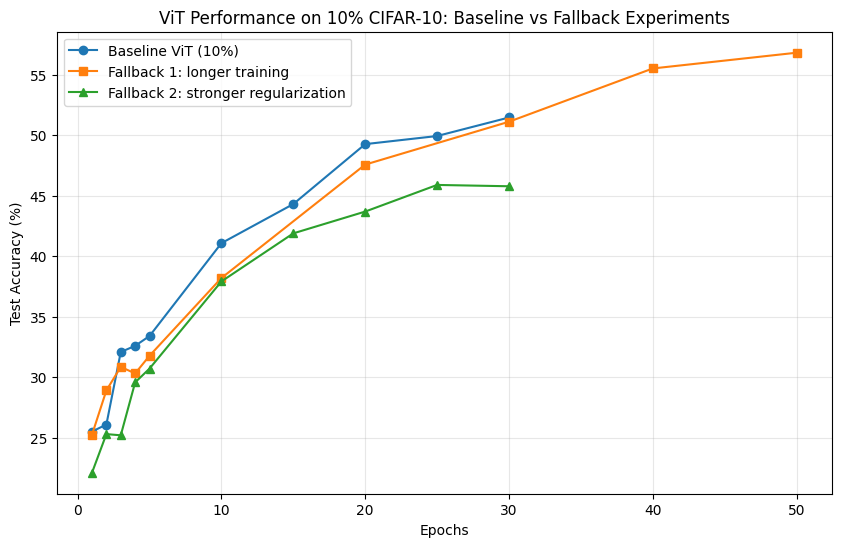

In [ ]:
epochs_base = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]
epochs_fb1 = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50]
epochs_fb2 = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]

plt.figure(figsize=(10, 6))

plt.plot(epochs_base, results_vit[0]["test_acc"], label="Baseline ViT (10%)", marker='o')
plt.plot(epochs_fb1, results_vit_fallback1["test_acc"], label="Fallback 1: longer training", marker='s')
plt.plot(epochs_fb2, results_vit_fallback2["test_acc"], label="Fallback 2: stronger regularization", marker='^')

plt.xlabel("Epochs")
plt.ylabel("Test Accuracy (%)")
plt.title("ViT Performance on 10% CIFAR-10: Baseline vs Fallback Experiments")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The main problem with ViT on 10% of the data is more like optimization/convergence difficulty than severe overfitting.
